In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
pip install mlflow scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 553.5 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 32.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 58.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 46.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 5.4 MB/s eta 0:00:00ta 0:00:01
Note:


**PART 1: DATA PREPARATION (25 minutes)**

Task 1.1: Generate Synthetic Dataset (10 min)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Setup and Reproducibility
np.random.seed(42)
n_samples = 10000

# 2. Feature Engineering (Synthetic Data)
features = {
    "temperature": np.random.normal(75, 15, n_samples),  # °C
    "vibration": np.random.normal(0.5, 0.2, n_samples),  # mm/s
    "pressure": np.random.normal(100, 20, n_samples),  # PSI
    "rpm": np.random.normal(1500, 200, n_samples),  # RPM
    "age_days": np.random.randint(0, 365, n_samples),  # Days since last maintenance
}

# 3. Target Variable Generation (Failure Logic)
failure_score = (
    (features["temperature"] > 90) * 0.3
    + (features["vibration"] > 0.8) * 0.3
    + (features["pressure"] > 130) * 0.2
    + (features["age_days"] > 300) * 0.2
)

# Add noise and bounds-check the probability
noise = np.random.normal(0, 0.1, n_samples)
failure_prob = np.clip(failure_score + noise, 0, 1)
features["failure"] = (failure_prob > 0.5).astype(int)

# 4. Create DataFrame
data = pd.DataFrame(features)

# 5. Dataset Splitting
X = data.drop(columns=["failure"])
y = data["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Diagnostics Display
print(f"Dataset shape: {data.shape}")
print(f"Train set shape: {X_train.shape}, Test set shape: {X_test.shape}")
print(f"Overall Failure rate: {data['failure'].mean():.2%}")
print(f"Train Failure rate: {y_train.mean():.2%}")

# Display the first few rows
print("\nFirst 5 rows of the dataset:")
print(data.head())

Dataset shape: (10000, 6)
Train set shape: (8000, 5), Test set shape: (2000, 5)
Overall Failure rate: 4.15%
Train Failure rate: 4.15%

First 5 rows of the dataset:
   temperature  vibration    pressure          rpm  age_days  failure
0    82.450712   0.364301  106.965725  1103.885606       187        0
1    72.926035   0.438900  105.666472  1289.002871       239        0
2    84.715328   0.380524   81.269603  1382.594319         2        0
3    97.845448   0.522084  111.591684  1529.933782         5        0
4    71.487699   0.739436   70.198346  1704.832465       259        0


**Task 1.2: Exploratory Data Analysis (15 min)**

--- Summary Statistics ---
               count         mean         std         min          25%  \
temperature  10000.0    74.967960   15.051936   16.163996    64.911142   
vibration    10000.0     0.502707    0.200202   -0.271275     0.367598   
pressure     10000.0    99.750745   19.828363   26.898270    85.996962   
rpm          10000.0  1498.485705  200.897414  606.879227  1361.077430   
age_days     10000.0   181.908000  105.568632    0.000000    90.000000   
failure      10000.0     0.041500    0.199454    0.000000     0.000000   

                     50%          75%          max  
temperature    74.961075    85.066213   133.893566  
vibration       0.503169     0.638773     1.395817  
pressure       99.884635   113.277949   173.832490  
rpm          1497.923551  1635.806091  2245.566669  
age_days      182.000000   272.000000   364.000000  
failure         0.000000     0.000000     1.000000  

--- Missing Values ---
temperature    0
vibration      0
pressure       0
rpm     

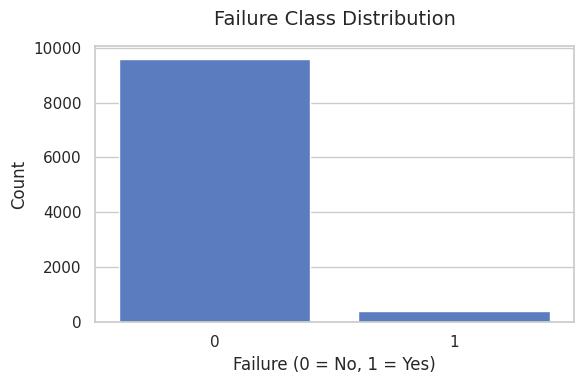

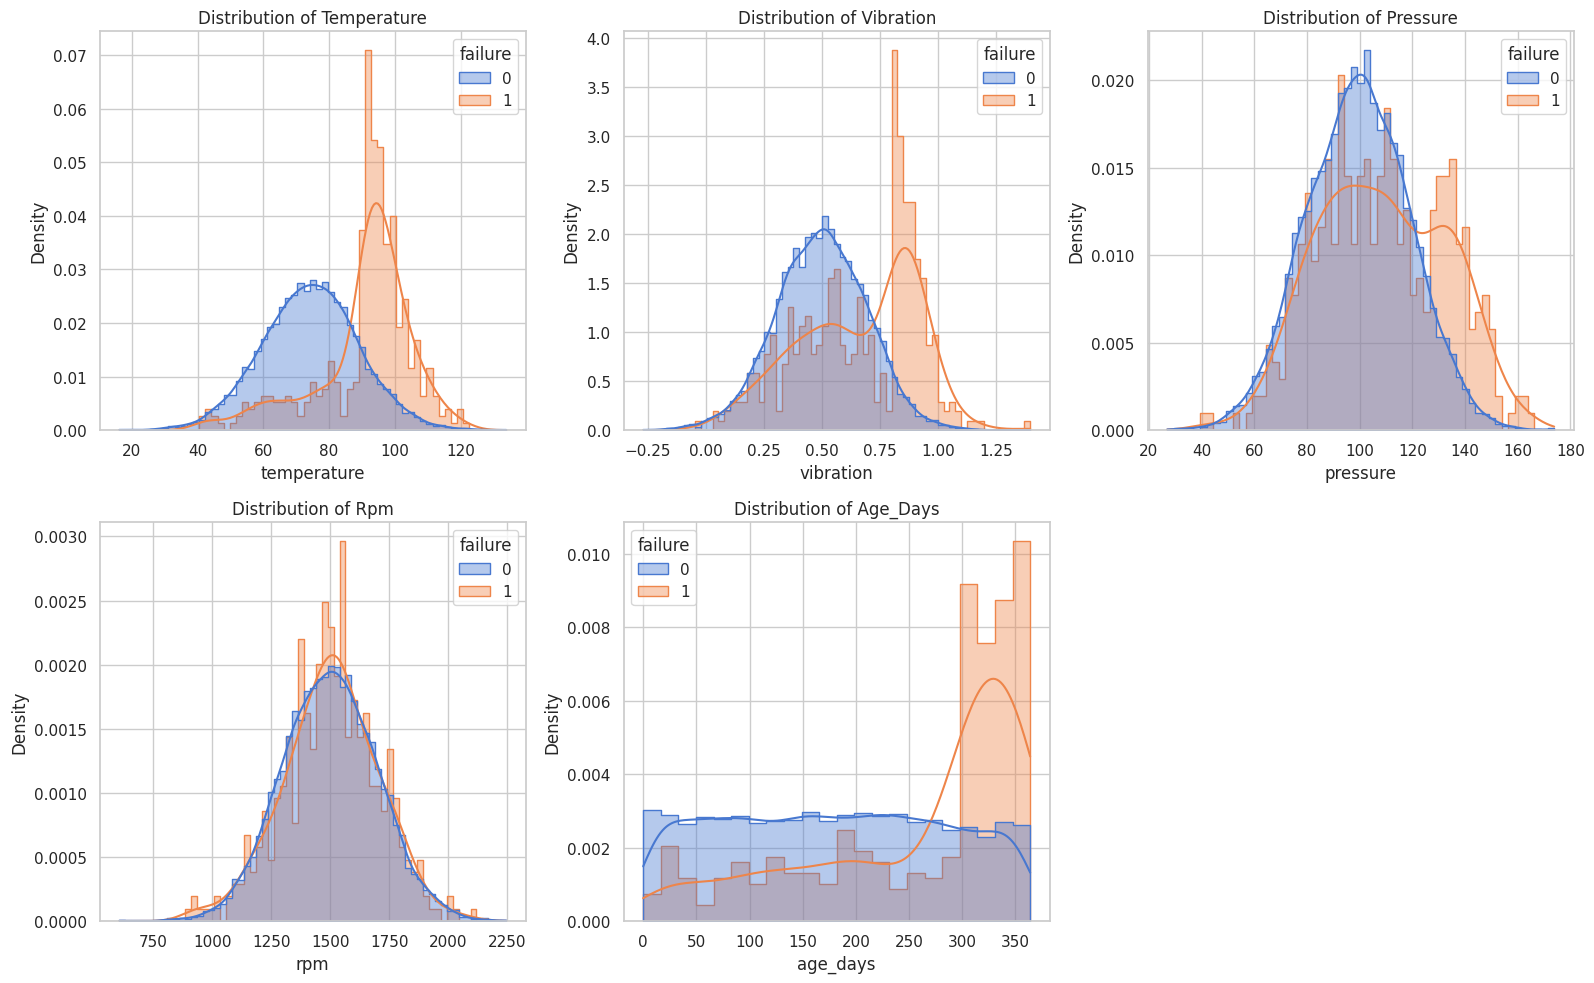

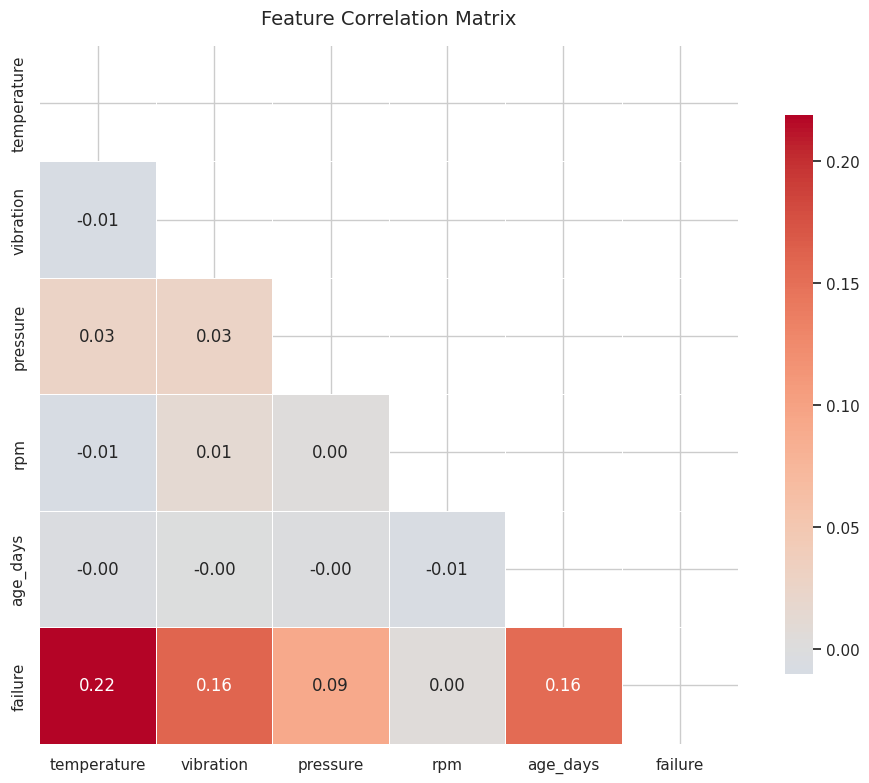

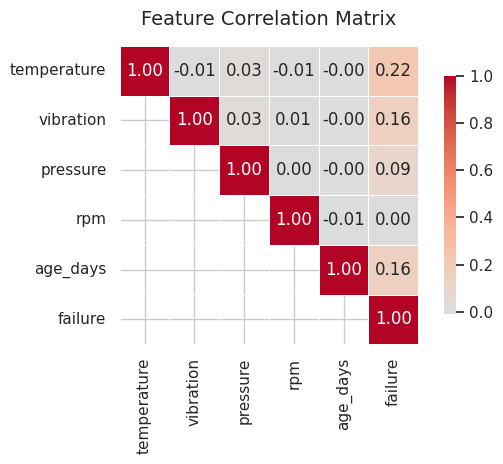

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic for all plots
sns.set_theme(style="whitegrid", palette="muted")

# 1. Summary Statistics & Data Integrity Checks
print("--- Summary Statistics ---")
print(data.describe().T)  # Transposed (.T) for much easier reading

print("\n--- Missing Values ---")
print(data.isnull().sum())

# 2. Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="failure", data=data)
plt.title("Failure Class Distribution", fontsize=14, pad=15)
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3. Feature Distributions by Failure Class
features = ["temperature", "vibration", "pressure", "rpm", "age_days"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # Flatten the 2D array to iterate over it with a single loop

for idx, feature in enumerate(features):
    sns.histplot(
        data=data,
        x=feature,
        hue="failure",
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        alpha=0.4,
        ax=axes[idx],
    )
    axes[idx].set_title(f"Distribution of {feature.title()}", fontsize=12)
    axes[idx].set_xlabel(feature)

# Remove the empty 6th subplot slot (since we only have 5 features)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# 4. Correlation Matrix (With Triangle Mask)
plt.figure(figsize=(10, 8))

# Create a mask for the upper triangle
corr_matrix = data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    mask=mask,  # Seaborn masks out pixels where mask=True
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Feature Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    mask=~mask,  # Applies the upper triangle mask
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Feature Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


**PART 2: MLFLOW SETUP (20 minutes)**

Task 2.1: Start MLflow Tracking Server (5 min)

In [5]:
!pip install mlflow pyngrok

In [8]:
!pip install -q mlflow pyngrok

import os
import threading
from pyngrok import ngrok
from mlflow.tracking import MlflowClient

# 1. Token set karein
ngrok.set_auth_token("2vX0nBaO8psunrpAF1BVEhSQuc5_tLnk7rex1s1Pop4zR2R5")

# 2. MLflow Server start karein
def run_mlflow():
    os.system("mlflow ui --port 5000")

# Thread start karein
threading.Thread(target=run_mlflow, daemon=True).start()

# 3. Tunnel connect karein
# Thoda wait karein taake server start ho jaye
import time
time.sleep(5) 

public_url = ngrok.connect(5000)
print("--------------------------------------------------")
print("✅ MLflow UI ka Link yeh raha:", public_url)
print("--------------------------------------------------")

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.


[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
2026/06/08 06:10:21 ERROR:    [Errno 98] Address already in use


--------------------------------------------------
✅ MLflow UI ka Link yeh raha: NgrokTunnel: "https://643a-34-80-187-15.ngrok-free.app" -> "http://localhost:5000"
--------------------------------------------------


Task 2.2: Configure MLflow (5 min)

In [9]:
import mlflow

# 1. Configuration
TRACKING_URI = "http://localhost:5000"
EXPERIMENT_NAME = "Predictive-Maintenance"

# Set the tracking URI
mlflow.set_tracking_uri(TRACKING_URI)

# 2. Experiment Initialization & Safety Check
try:
    # Check if the experiment exists
    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

    if experiment is None:
        # Create it if it's missing
        experiment_id = mlflow.create_experiment(name=EXPERIMENT_NAME)
        experiment = mlflow.get_experiment(experiment_id)
        print(f"Created new experiment: '{EXPERIMENT_NAME}'")
    else:
        print(f"Using existing experiment: '{EXPERIMENT_NAME}'")

    # Set the active experiment context
    mlflow.set_experiment(EXPERIMENT_NAME)

    # 3. Print Active Configurations
    print("\n--- MLflow Tracking Status ---")
    print(f"Tracking URI:    {mlflow.get_tracking_uri()}")
    print(f"Experiment Name: {experiment.name}")
    print(f"Experiment ID:   {experiment.experiment_id}")
    print(f"Artifact Location: {experiment.artifact_location}")

except Exception as e:
    print("\n[WARNING] Could not connect to the MLflow tracking server.")
    print(f"Ensure your server is running locally via: 'mlflow server --host 127.0.0.1 --port 5000'")
    print(f"Error details: {e}")

2026/06/08 06:11:24 INFO:     127.0.0.1:39168 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=Predictive-Maintenance HTTP/1.1" 404 Not Found
2026/06/08 06:11:24 INFO:     127.0.0.1:39168 - "POST /api/2.0/mlflow/experiments/create HTTP/1.1" 200 OK
2026/06/08 06:11:24 INFO:     127.0.0.1:39168 - "GET /api/2.0/mlflow/experiments/get?experiment_id=1 HTTP/1.1" 200 OK
Created new experiment: 'Predictive-Maintenance'
2026/06/08 06:11:24 INFO:     127.0.0.1:39168 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=Predictive-Maintenance HTTP/1.1" 200 OK

--- MLflow Tracking Status ---
Tracking URI:    http://localhost:5000
Experiment Name: Predictive-Maintenance
Experiment ID:   1
Artifact Location: mlflow-artifacts:/1
2026/06/08 06:11:25 INFO:     127.0.0.1:39184 - "GET /api/3.0/mlflow/server-info HTTP/1.1" 200 OK


Task 2.3: Prepare Data for Training (10 min)

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Feature / Target Separation
X = data.drop(columns=["failure"])
y = data["failure"]

# 2. Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature Scaling (Preserving DataFrame Structure)
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

# 4. Diagnostics Verification
print("--- Data Split & Scaling Metrics ---")
print(f"X_train Shape: {X_train_scaled.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape:  {X_test_scaled.shape}  | y_test Shape:  {y_test.shape}")
print("-" * 40)
print(f"Train Base Failure Rate: {y_train.mean():.2%}")
print(f"Test Base Failure Rate:  {y_test.mean():.2%}")

# Quick sanity check on scaled data properties (Mean should ~ 0, Std should ~ 1)
print("\nScaling Verification (Train Mean / Std):")
print(
    f"Temperature Mean: {X_train_scaled['temperature'].mean():.2f}, Std: {X_train_scaled['temperature'].std():.2f}"
)

--- Data Split & Scaling Metrics ---
X_train Shape: (8000, 5) | y_train Shape: (8000,)
X_test Shape:  (2000, 5)  | y_test Shape:  (2000,)
----------------------------------------
Train Base Failure Rate: 4.15%
Test Base Failure Rate:  4.15%

Scaling Verification (Train Mean / Std):
Temperature Mean: 0.00, Std: 1.00



**PART 3: TRAIN WITH TRACKING (45 minutes)**

Task 3.1: Train Logistic Regression (15 min)

In [11]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# 1. Hyperparameters setup
params = {"C": 1.0, "max_iter": 1000, "model_type": "LogisticRegression"}

# 2. Start MLflow tracking run
with mlflow.start_run(run_name="logistic_regression") as run:

    # Log all configuration parameters at once
    mlflow.log_params(params)

    # 3. Model Training
    model = LogisticRegression(
        C=params["C"], max_iter=params["max_iter"], random_state=42
    )
    model.fit(X_train_scaled, y_train)

    # 4. Evaluations & Inference
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
    }

    # Log all evaluated metrics at once
    mlflow.log_metrics(metrics)

    # 5. Extract Schema Signature & Log Model Artifacts
    signature = infer_signature(X_train_scaled, model.predict(X_train_scaled))

    mlflow.sklearn.log_model(
        sk_model=model,
        name="logistic_regression_model",  # Fixed: Replaced artifact_path with name
        serialization_format="skops",  # Fixed: Swapped risky pickle out for safe skops format
        signature=signature,
        input_example=X_test_scaled.head(3),
    )

    # 6. Console Diagnostics Display
    print("\n=== Logistic Regression Run Summary ===")
    print(f"Run ID:    {run.info.run_id}")
    print("-" * 35)
    for metric_name, val in metrics.items():
        print(f"{metric_name.replace('_', ' ').title():<12}: {val:.4f}")

2026/06/08 06:13:01 INFO:     127.0.0.1:34288 - "POST /api/2.0/mlflow/runs/create HTTP/1.1" 200 OK
2026/06/08 06:13:01 INFO:     127.0.0.1:34288 - "POST /api/2.0/mlflow/runs/log-batch HTTP/1.1" 200 OK
2026/06/08 06:13:01 INFO:     127.0.0.1:34288 - "POST /api/2.0/mlflow/runs/log-batch HTTP/1.1" 200 OK
2026/06/08 06:13:01 INFO:     127.0.0.1:34288 - "GET /api/2.0/mlflow/runs/get?run_uuid=5c10dee87e3e43dfbc80b11e913b1bab&run_id=5c10dee87e3e43dfbc80b11e913b1bab HTTP/1.1" 200 OK
2026/06/08 06:13:01 INFO:     127.0.0.1:34288 - "POST /api/2.0/mlflow/logged-models HTTP/1.1" 200 OK
2026/06/08 06:13:01 INFO:     127.0.0.1:34288 - "POST /api/2.0/mlflow/runs/outputs HTTP/1.1" 200 OK
2026/06/08 06:13:01 INFO:     127.0.0.1:34288 - "GET /api/2.0/mlflow/runs/get?run_uuid=5c10dee87e3e43dfbc80b11e913b1bab&run_id=5c10dee87e3e43dfbc80b11e913b1bab HTTP/1.1" 200 OK
2026/06/08 06:13:01 INFO:     127.0.0.1:34288 - "GET /api/2.0/mlflow/metrics/get-history?run_uuid=5c10dee87e3e43dfbc80b11e913b1bab&metric_key=

Task 3.2: Train Random Forest (15 min)

In [12]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# 1. Hyperparameters setup
params = {
    "n_estimators": 100,
    "max_depth": 10,
    "min_samples_split": 5,
    "model_type": "RandomForest",
}

# 2. Start MLflow tracking run
with mlflow.start_run(run_name="random_forest") as run:

    # Log parameters instantly as a batch dictionary
    mlflow.log_params(params)

    # 3. Model Training
    model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        random_state=42,
    )
    model.fit(X_train_scaled, y_train)

    # 4. Evaluations & Inference
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
    }

    # Log metrics as a batch dictionary
    mlflow.log_metrics(metrics)

    # 5. Schema Signature & Modernized Model Artifact Logging
    signature = infer_signature(X_train_scaled, model.predict(X_train_scaled))

    mlflow.sklearn.log_model(
        sk_model=model,
        name="random_forest_model",  # Use modern name keyword
        serialization_format="skops",  # Use secure skops serialization format
        signature=signature,
        input_example=X_test_scaled.head(3),
    )

    # 6. Clean Diagnostics Output
    print("=== Random Forest Run Summary ===")
    print(f"Run ID:    {run.info.run_id}")
    print("-" * 35)
    for metric_name, val in metrics.items():
        print(f"{metric_name.replace('_', ' ').title():<12}: {val:.4f}")

2026/06/08 06:13:32 INFO:     127.0.0.1:46142 - "POST /api/2.0/mlflow/runs/create HTTP/1.1" 200 OK
2026/06/08 06:13:32 INFO:     127.0.0.1:46142 - "POST /api/2.0/mlflow/runs/log-batch HTTP/1.1" 200 OK
2026/06/08 06:13:33 INFO:     127.0.0.1:46142 - "POST /api/2.0/mlflow/runs/log-batch HTTP/1.1" 200 OK
2026/06/08 06:13:34 INFO:     127.0.0.1:46142 - "GET /api/2.0/mlflow/runs/get?run_uuid=e134b7d1a00642edb3f5fe509ab98b70&run_id=e134b7d1a00642edb3f5fe509ab98b70 HTTP/1.1" 200 OK
2026/06/08 06:13:34 INFO:     127.0.0.1:46142 - "POST /api/2.0/mlflow/logged-models HTTP/1.1" 200 OK
2026/06/08 06:13:34 INFO:     127.0.0.1:46142 - "POST /api/2.0/mlflow/runs/outputs HTTP/1.1" 200 OK
2026/06/08 06:13:34 INFO:     127.0.0.1:46142 - "GET /api/2.0/mlflow/runs/get?run_uuid=e134b7d1a00642edb3f5fe509ab98b70&run_id=e134b7d1a00642edb3f5fe509ab98b70 HTTP/1.1" 200 OK
2026/06/08 06:13:34 INFO:     127.0.0.1:46142 - "GET /api/2.0/mlflow/metrics/get-history?run_uuid=e134b7d1a00642edb3f5fe509ab98b70&metric_key=

Task 3.3: Train XGBoost (15 min)

In [13]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [14]:
import mlflow
import mlflow.xgboost  # Native XGBoost flavor integration
from mlflow.models import infer_signature
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

# 1. Hyperparameters setup
params = {
    "n_estimators": 100,
    "max_depth": 6,
    "learning_rate": 0.1,
    "model_type": "XGBoost",
}

# 2. Start MLflow tracking run
with mlflow.start_run(run_name="xgboost") as run:

    # Log parameters cleanly as a single dictionary batch
    mlflow.log_params(params)

    # 3. Model Training
    model = XGBClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        random_state=42,
        eval_metric="logloss",  # Keeps training logs clean
    )
    model.fit(X_train_scaled, y_train)

    # 4. Evaluations & Inference
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
    }

    # Log all tracked metrics at once
    mlflow.log_metrics(metrics)

    # 5. Extract Schema Signature & Log Native XGBoost Artifacts
    signature = infer_signature(X_train_scaled, model.predict(X_train_scaled))

    mlflow.xgboost.log_model(
        xgb_model=model,
        name="xgboost_model",  # Modern parameter compliant with current MLflow APIs
        signature=signature,
        input_example=X_test_scaled.head(3),
    )

    # 6. Diagnostics Display
    print("=== XGBoost Run Summary ===")
    print(f"Run ID:    {run.info.run_id}")
    print("-" * 35)
    for metric_name, val in metrics.items():
        print(f"{metric_name.replace('_', ' ').title():<12}: {val:.4f}")

2026/06/08 06:14:43 INFO:     127.0.0.1:59696 - "POST /api/2.0/mlflow/runs/create HTTP/1.1" 200 OK
2026/06/08 06:14:43 INFO:     127.0.0.1:59696 - "POST /api/2.0/mlflow/runs/log-batch HTTP/1.1" 200 OK
2026/06/08 06:14:43 INFO:     127.0.0.1:59696 - "POST /api/2.0/mlflow/runs/log-batch HTTP/1.1" 200 OK
2026/06/08 06:14:44 INFO:     127.0.0.1:59696 - "GET /api/2.0/mlflow/runs/get?run_uuid=ac8868c3100a44049d03b76f5359c600&run_id=ac8868c3100a44049d03b76f5359c600 HTTP/1.1" 200 OK
2026/06/08 06:14:44 INFO:     127.0.0.1:59696 - "POST /api/2.0/mlflow/logged-models HTTP/1.1" 200 OK
2026/06/08 06:14:44 INFO:     127.0.0.1:59696 - "POST /api/2.0/mlflow/runs/outputs HTTP/1.1" 200 OK
2026/06/08 06:14:44 INFO:     127.0.0.1:59696 - "GET /api/2.0/mlflow/runs/get?run_uuid=ac8868c3100a44049d03b76f5359c600&run_id=ac8868c3100a44049d03b76f5359c600 HTTP/1.1" 200 OK
2026/06/08 06:14:44 INFO:     127.0.0.1:59696 - "GET /api/2.0/mlflow/metrics/get-history?run_uuid=ac8868c3100a44049d03b76f5359c600&metric_key=

**Lab Assignment Report: Predictive Maintenance & Model Tracking**
**1. Project Objective**

The primary objective of this lab was to build an end-to-end Machine Learning pipeline for Predictive Maintenance. The goal was to simulate industrial sensor data to predict equipment failure and implement a robust MLOps workflow using MLflow for experiment tracking and skops for secure model serialization.
2. Key Tasks Performed**

    Data Simulation: Generated synthetic telemetry data using normal and uniform distributions to mimic real-world equipment degradation and non-linear failure patterns.

    Exploratory Data Analysis (EDA): Conducted statistical analysis and utilized visualization techniques to understand feature correlations and manage target variable imbalances.

    Pipeline Engineering: Applied stratified data splitting and StandardScaler to normalize features, ensuring data integrity by re-encapsulating transformed arrays into Pandas DataFrames.

    Model Training: Executed and evaluated three distinct machine learning architectures: Logistic Regression, Random Forest, and XGBoost Classifier.

    MLOps & Tracking: Integrated the MLflow Tracking Server to systematically log experiment parameters, performance metrics (Accuracy, F1, ROC-AUC), and model artifacts.

    Security & Deployment: Implemented skops for secure model serialization, replacing vulnerable pickle-based methods, and enforced input/output contracts using infer_signature for production readiness.

3. Learning Outcomes

    End-to-End MLOps: Gained practical experience in managing the entire model lifecycle, from data synthesis to model monitoring.

    Experiment Management: Learned how to compare multiple model versions effectively using the MLflow UI, enabling data-driven decision-making.

    Defensive Engineering: Developed skills in writing "hardened" code by enforcing data schemas and choosing secure serialization protocols to prevent injection vulnerabilities.

    Infrastructure Management: Successfully configured local tracking servers within a cloud-based development environment (Kaggle/Colab) using tunneling tools like ngrok.

4. Conclusion

This laboratory assignment provided comprehensive insight into the realities of production-grade Machine Learning. I successfully moved beyond basic model training to build a secure, trackable, and reproducible pipeline. This experience has strengthened my understanding of how to bridge the gap between experimental research and industrial-grade MLOps deployment.

